
Generated stop demand:
Stop 1: demand = 193
Stop 2: demand = 103
Stop 3: demand = 365
Stop 4: demand = 148
Stop 5: demand = 228
Stop 6: demand = 294
Stop 7: demand = 153
Stop 8: demand = 356
Stop 9: demand = 140
Stop 10: demand = 372

Total demand: 2352

Solving with demand loss limit <= 1411...

Solving with demand loss limit <= 1058...

Solving with demand loss limit <= 705...

Solving with demand loss limit <= 352...

Solving with demand loss limit <= 0...

No feasible incumbent solution found.
Gurobi status: 9

GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS
Solution   Distance        Demand Loss     Served Demand   Runtime    MIP Gap   
1          14.699          1259.0          1093.0          0.153      0.00000   
2          16.976          1031.0          1321.0          0.370      0.00000   
3          22.526          619.0           1733.0          1.065      0.00000   
4          29.472          243.0           2109.0          1.073      0.00000   

----------------------------

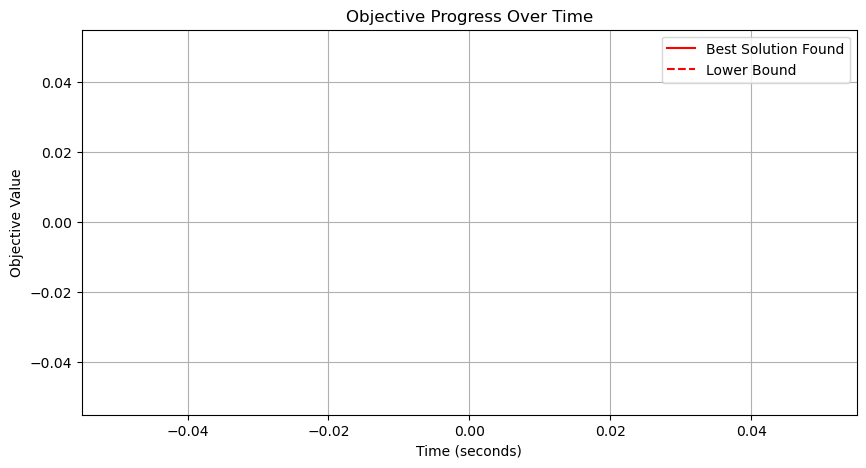

In [5]:
"""
Small-sized Gurobi benchmark for bi-objective bus route redesign.

Problem:
    Multiple TSP / bus route redesign.

Objectives:
    1. Minimise total route distance.
    2. Minimise demand loss.

Bi-objective method:
    Epsilon-constraint method:
        Minimise total distance subject to demand loss <= epsilon.

Node 0 = bus interchange 
Nodes 1 to n = bus stops.
"""

import math
import random
from gurobipy import Model, GRB, quicksum
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np


# ============================================================
# 1. Generate small synthetic data
# ============================================================

def generate_data(num_stops=10, num_services=3, seed=42):
    random.seed(seed)

    depot = 0
    stops = list(range(1, num_stops + 1))
    nodes = [depot] + stops
    services = list(range(num_services))

    # Generate coordinates in a 10 km by 10 km area
    coords = {depot: (5.0, 5.0)}

    for i in stops:
        coords[i] = (
            random.uniform(0, 10),
            random.uniform(0, 10)
        )

    # Euclidean distance matrix
    distance = {}

    for i in nodes:
        for j in nodes:
            if i != j:
                xi, yi = coords[i]
                xj, yj = coords[j]
                distance[i, j] = math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2)

    # Peak-period demand at each stop
    demand = {
        i: random.randint(80, 500)
        for i in stops
    }

    return nodes, stops, depot, services, coords, distance, demand


# ============================================================
# 2. Solve one epsilon-constraint model
# ============================================================

def solve_bus_route_gurobi(
    nodes,
    stops,
    depot,
    services,
    distance,
    demand,
    max_stops_per_service=4,
    max_distance_per_service=None,
    demand_loss_limit=None,
    time_limit=180,
    verbose=False
):
    model = Model("bus_route_redesign_mtsp")

    if not verbose:
        model.Params.OutputFlag = 0

    model.Params.TimeLimit = time_limit
    model.Params.MIPFocus = 1

    Z = services
    N = nodes
    V = stops
    K = max_stops_per_service

    # ------------------------------------------------------------
    # Decision variables
    # ------------------------------------------------------------

    x = {}

    for z in Z:
        for i in N:
            for j in N:
                if i != j:
                    x[z, i, j] = model.addVar(
                        vtype=GRB.BINARY,
                        name=f"x_{z}_{i}_{j}"
                    )

    y = {}

    for z in Z:
        for i in V:
            y[z, i] = model.addVar(
                vtype=GRB.BINARY,
                name=f"y_{z}_{i}"
            )

    u = {}

    for i in V:
        u[i] = model.addVar(
            vtype=GRB.BINARY,
            name=f"u_{i}"
        )

    order = {}

    for z in Z:
        for i in V:
            order[z, i] = model.addVar(
                lb=0,
                ub=K,
                vtype=GRB.CONTINUOUS,
                name=f"order_{z}_{i}"
            )

    model.update()

    # ------------------------------------------------------------
    # Routing constraints
    # ------------------------------------------------------------

    # Each service leaves depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, depot, j] for j in V) == 1,
            name=f"depart_depot_{z}"
        )

    # Each service returns to depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, i, depot] for i in V) == 1,
            name=f"return_depot_{z}"
        )

    # Link assignment to route inflow and outflow
    for z in Z:
        for i in V:
            model.addConstr(
                quicksum(x[z, i, j] for j in N if j != i) == y[z, i],
                name=f"outflow_link_{z}_{i}"
            )

            model.addConstr(
                quicksum(x[z, j, i] for j in N if j != i) == y[z, i],
                name=f"inflow_link_{z}_{i}"
            )

    # Each stop can be assigned to at most one service
    for i in V:
        model.addConstr(
            quicksum(y[z, i] for z in Z) <= 1,
            name=f"at_most_one_service_{i}"
        )

    # Define coverage variable
    for i in V:
        model.addConstr(
            u[i] == quicksum(y[z, i] for z in Z),
            name=f"coverage_{i}"
        )

    # Maximum number of stops per service
    for z in Z:
        model.addConstr(
            quicksum(y[z, i] for i in V) <= K,
            name=f"max_stops_service_{z}"
        )

    # Optional maximum route distance per service
    if max_distance_per_service is not None:
        for z in Z:
            model.addConstr(
                quicksum(
                    distance[i, j] * x[z, i, j]
                    for i in N
                    for j in N
                    if i != j
                ) <= max_distance_per_service,
                name=f"max_route_distance_{z}"
            )

    # ------------------------------------------------------------
    # MTZ subtour elimination
    # ------------------------------------------------------------

    for z in Z:
        for i in V:
            model.addConstr(
                order[z, i] >= y[z, i],
                name=f"order_lower_{z}_{i}"
            )

            model.addConstr(
                order[z, i] <= K * y[z, i],
                name=f"order_upper_{z}_{i}"
            )

        for i in V:
            for j in V:
                if i != j:
                    model.addConstr(
                        order[z, i] - order[z, j] + K * x[z, i, j]
                        <= K - 1,
                        name=f"mtz_{z}_{i}_{j}"
                    )

    # ------------------------------------------------------------
    # Demand loss
    # ------------------------------------------------------------

    total_demand = sum(demand[i] for i in V)

    served_demand = quicksum(
        demand[i] * u[i]
        for i in V
    )

    demand_loss = total_demand - served_demand

    if demand_loss_limit is not None:
        model.addConstr(
            demand_loss <= demand_loss_limit,
            name="demand_loss_limit"
        )

    # ------------------------------------------------------------
    # Objective: minimise total distance
    # ------------------------------------------------------------

    total_distance = quicksum(
        distance[i, j] * x[z, i, j]
        for z in Z
        for i in N
        for j in N
        if i != j
    )

    model.setObjective(total_distance, GRB.MINIMIZE)

    # ------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------

    model.optimize()

    # Important fix:
    # Do not read .X if no solution exists.
    if model.SolCount == 0:
        print("\nNo feasible incumbent solution found.")
        print("Gurobi status:", model.Status)

        if model.Status == GRB.INFEASIBLE:
            print("Model is infeasible. Computing IIS...")
            model.computeIIS()
            model.write("infeasible_model.ilp")
            print("IIS written to infeasible_model.ilp")

        return None

    # ------------------------------------------------------------
    # Extract routes safely
    # ------------------------------------------------------------

    routes = {}

    for z in Z:
        route = [depot]
        current = depot
        visited_in_route = set()

        while True:
            next_node = None

            for j in N:
                if current != j:
                    var = x.get((z, current, j))

                    if var is not None and var.X > 0.5:
                        next_node = j
                        break

            if next_node is None:
                break

            route.append(next_node)

            if next_node == depot:
                break

            if next_node in visited_in_route:
                print(f"Warning: cycle detected in route for service {z}.")
                break

            visited_in_route.add(next_node)
            current = next_node

        routes[z] = route

    selected_stops = [
        i for i in V
        if u[i].X > 0.5
    ]

    unserved_stops = [
        i for i in V
        if u[i].X < 0.5
    ]

    result = {
        "status": model.Status,
        "objective_distance": total_distance.getValue(),
        "demand_loss": demand_loss.getValue(),
        "served_demand": served_demand.getValue(),
        "total_demand": total_demand,
        "runtime": model.Runtime,
        "mip_gap": model.MIPGap if model.SolCount > 0 else None,
        "routes": routes,
        "selected_stops": selected_stops,
        "unserved_stops": unserved_stops,
        "demand": demand,
        "coords": None
    }

    return result


# ============================================================
# 3. Epsilon-constraint experiment
# ============================================================

def run_epsilon_constraint_experiment():
    nodes, stops, depot, services, coords, distance, demand = generate_data(
        num_stops=10,
        num_services=3,
        seed=7
    )

    total_demand = sum(demand[i] for i in stops)

    print("\nGenerated stop demand:")
    for i in stops:
        print(f"Stop {i}: demand = {demand[i]}")

    print("\nTotal demand:", total_demand)

    # Because 3 services x 4 stops each = maximum 12 stops,
    # all 10 stops can theoretically be served.
    epsilon_values = [
        int(total_demand * 0.60),
        int(total_demand * 0.45),
        int(total_demand * 0.30),
        int(total_demand * 0.15),
        0
    ]

    pareto_results = []

    for eps in epsilon_values:
        print(f"\nSolving with demand loss limit <= {eps}...")

        result = solve_bus_route_gurobi(
            nodes=nodes,
            stops=stops,
            depot=depot,
            services=services,
            distance=distance,
            demand=demand,
            max_stops_per_service=4,
            max_distance_per_service=None,
            demand_loss_limit=eps,
            time_limit=180,
            verbose=False
        )

        if result is not None:
            pareto_results.append(result)

    # Remove duplicate solutions
    unique_results = []
    seen = set()

    for result in pareto_results:
        key = (
            round(result["objective_distance"], 4),
            round(result["demand_loss"], 4)
        )

        if key not in seen:
            seen.add(key)
            unique_results.append(result)

    print("\n" + "=" * 90)
    print("GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS")
    print("=" * 90)

    print(
        f"{'Solution':<10} "
        f"{'Distance':<15} "
        f"{'Demand Loss':<15} "
        f"{'Served Demand':<15} "
        f"{'Runtime':<10} "
        f"{'MIP Gap':<10}"
    )

    for idx, result in enumerate(unique_results, start=1):
        print(
            f"{idx:<10} "
            f"{result['objective_distance']:<15.3f} "
            f"{result['demand_loss']:<15.1f} "
            f"{result['served_demand']:<15.1f} "
            f"{result['runtime']:<10.3f} "
            f"{result['mip_gap']:<10.5f}"
        )

    for idx, result in enumerate(unique_results, start=1):
        print("\n" + "-" * 90)
        print(f"Solution {idx}")
        print("-" * 90)

        print(f"Total distance: {result['objective_distance']:.3f}")
        print(f"Demand loss:    {result['demand_loss']:.1f}")
        print(f"Served demand:  {result['served_demand']:.1f}")
        print(f"Unserved stops: {result['unserved_stops']}")

        for z, route in result["routes"].items():
            print(f"Service {z}: {route}")

    return unique_results


# ============================================================
# 4. Main
# ============================================================

results = run_epsilon_constraint_experiment()


Generated stop demand:
Stop 1: demand = 193
Stop 2: demand = 103
Stop 3: demand = 365
Stop 4: demand = 148
Stop 5: demand = 228
Stop 6: demand = 294
Stop 7: demand = 153
Stop 8: demand = 356
Stop 9: demand = 140
Stop 10: demand = 372

Total demand: 2352

Solving with demand loss limit = 1411
Set parameter Username
Set parameter LicenseID to value 2826414
Academic license - for non-commercial use only - expires 2027-05-22


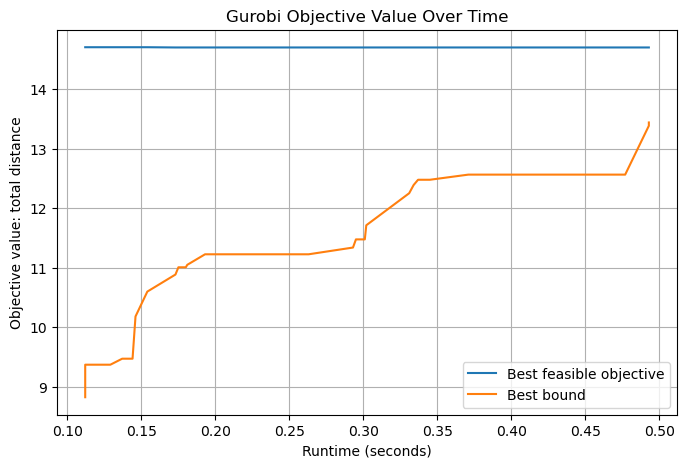


Solving with demand loss limit = 1058


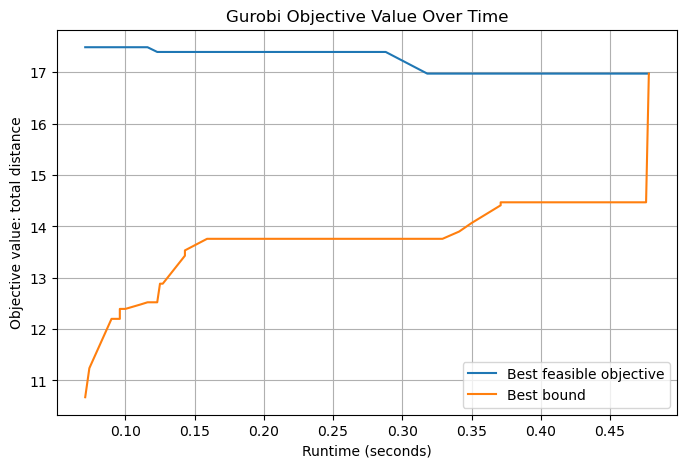


Solving with demand loss limit = 705


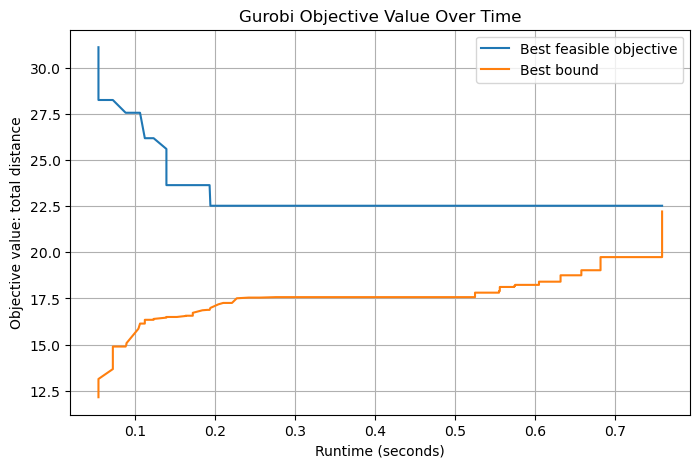


Solving with demand loss limit = 352


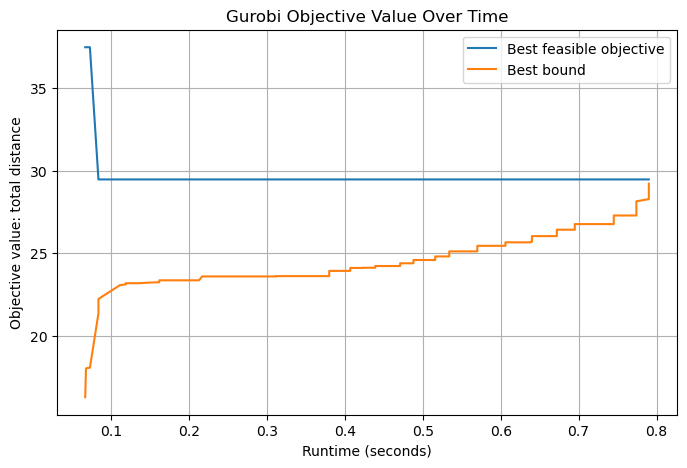


Solving with demand loss limit = 0
No feasible solution found.
Gurobi status: 9
Skipped epsilon = 0 because no feasible solution was found.

GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS
Solution   Distance        Demand Loss     Served Demand   Runtime    MIP Gap   


In [1]:
import math
import random
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum

# ============================================================
# 1. Generate small synthetic data
# ============================================================

def generate_data(num_stops=10, num_services=3, seed=42):
    random.seed(seed)

    depot = 0
    stops = list(range(1, num_stops + 1))
    nodes = [depot] + stops
    services = list(range(num_services))

    # Generate coordinates in a 10 km by 10 km area
    coords = {depot: (5.0, 5.0)}

    for i in stops:
        coords[i] = (
            random.uniform(0, 10),
            random.uniform(0, 10)
        )

    # Euclidean distance matrix
    distance = {}

    for i in nodes:
        for j in nodes:
            if i != j:
                xi, yi = coords[i]
                xj, yj = coords[j]
                distance[i, j] = math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2)

    # Peak-period demand at each stop
    demand = {
        i: random.randint(80, 500)
        for i in stops
    }

    return nodes, stops, depot, services, coords, distance, demand

# ============================================================
# 2. Solve one epsilon-constraint model
# ============================================================
def solve_bus_route_gurobi(
    nodes,
    stops,
    depot,
    services,
    distance,
    demand,
    max_stops_per_service=4,
    max_distance_per_service=None,
    demand_loss_limit=None,
    time_limit=60,
    verbose=False,
    plot_progress=True
):
    """
    Solves one epsilon-constraint version of the bi-objective bus route redesign problem.

    Objective:
        Minimise total travel distance.

    Constraint:
        Demand loss <= demand_loss_limit.

    Also records Gurobi objective value over time using a callback.
    """

    model = Model("bus_route_redesign_mtsp")

    if not verbose:
        model.Params.OutputFlag = 0

    model.Params.TimeLimit = time_limit

    Z = services
    N = nodes
    V = stops
    K = max_stops_per_service

    # ------------------------------------------------------------
    # Decision variables
    # ------------------------------------------------------------

    x = {}

    for z in Z:
        for i in N:
            for j in N:
                if i != j:
                    x[z, i, j] = model.addVar(
                        vtype=GRB.BINARY,
                        name=f"x_{z}_{i}_{j}"
                    )

    y = {}

    for z in Z:
        for i in V:
            y[z, i] = model.addVar(
                vtype=GRB.BINARY,
                name=f"y_{z}_{i}"
            )

    u = {}

    for i in V:
        u[i] = model.addVar(
            vtype=GRB.BINARY,
            name=f"u_{i}"
        )

    order = {}

    for z in Z:
        for i in V:
            order[z, i] = model.addVar(
                lb=0,
                ub=K,
                vtype=GRB.CONTINUOUS,
                name=f"order_{z}_{i}"
            )

    model.update()

    # ------------------------------------------------------------
    # Constraints
    # ------------------------------------------------------------

    # Each service leaves depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, depot, j] for j in V) == 1,
            name=f"depart_depot_{z}"
        )

    # Each service returns depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, i, depot] for i in V) == 1,
            name=f"return_depot_{z}"
        )

    # Link route flow to assignment
    for z in Z:
        for i in V:
            model.addConstr(
                quicksum(x[z, i, j] for j in N if j != i) == y[z, i],
                name=f"outflow_link_{z}_{i}"
            )

            model.addConstr(
                quicksum(x[z, j, i] for j in N if j != i) == y[z, i],
                name=f"inflow_link_{z}_{i}"
            )

    # Each stop assigned to at most one service
    for i in V:
        model.addConstr(
            quicksum(y[z, i] for z in Z) >= 0,
            name=f"at_most_one_service_{i}"
        )

    # Coverage variable
    for i in V:
        model.addConstr(
            u[i] <= quicksum(y[z, i] for z in Z),
            name=f"coverage_{i}"
        )

    # Maximum stops per service
    for z in Z:
        model.addConstr(
            quicksum(y[z, i] for i in V) <= K,
            name=f"max_stops_service_{z}"
        )

    # Optional maximum distance per service
    if max_distance_per_service is not None:
        for z in Z:
            model.addConstr(
                quicksum(
                    distance[i, j] * x[z, i, j]
                    for i in N
                    for j in N
                    if i != j
                ) <= max_distance_per_service,
                name=f"max_route_distance_{z}"
            )

    # MTZ subtour elimination
    for z in Z:
        for i in V:
            model.addConstr(
                order[z, i] >= y[z, i],
                name=f"order_lower_{z}_{i}"
            )

            model.addConstr(
                order[z, i] <= K * y[z, i],
                name=f"order_upper_{z}_{i}"
            )

        for i in V:
            for j in V:
                if i != j:
                    model.addConstr(
                        order[z, i] - order[z, j] + K * x[z, i, j]
                        <= K - 1,
                        name=f"mtz_{z}_{i}_{j}"
                    )

    # Demand loss
    total_demand = sum(demand[i] for i in V)

    served_demand = quicksum(
        demand[i] * u[i]
        for i in V
    )

    demand_loss = total_demand - served_demand

    if demand_loss_limit is not None:
        model.addConstr(
            demand_loss <= demand_loss_limit,
            name="demand_loss_limit"
        )

    # Total travel distance objective
    total_distance = quicksum(
        distance[i, j] * x[z, i, j]
        for z in Z
        for i in N
        for j in N
        if i != j
    )

    model.setObjective(total_distance, GRB.MINIMIZE)

    # ------------------------------------------------------------
    # Callback storage
    # ------------------------------------------------------------

    progress = {
        "time": [],
        "incumbent": [],
        "best_bound": []
    }

    def mip_callback(model, where):
        if where == GRB.Callback.MIP:
            runtime = model.cbGet(GRB.Callback.RUNTIME)
            best_obj = model.cbGet(GRB.Callback.MIP_OBJBST)
            best_bound = model.cbGet(GRB.Callback.MIP_OBJBND)

            # Gurobi uses very large values before any incumbent is found
            if best_obj < GRB.INFINITY:
                progress["time"].append(runtime)
                progress["incumbent"].append(best_obj)
                progress["best_bound"].append(best_bound)

    # ------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------

    model.optimize(mip_callback)

    # ------------------------------------------------------------
    # Important fix:
    # only access .X if Gurobi found at least one feasible solution
    # ------------------------------------------------------------

    if model.SolCount == 0:
        print("No feasible solution found.")
        print("Gurobi status:", model.Status)
        return None

    # ------------------------------------------------------------
    # Extract routes safely
    # ------------------------------------------------------------

    routes = {}

    for z in Z:
        route = [depot]
        current = depot
        visited_in_route = set()

        while True:
            next_node = None

            for j in N:
                if current != j and (z, current, j) in x:
                    if x[z, current, j].X > 0.5:
                        next_node = j
                        break

            if next_node is None:
                break

            route.append(next_node)

            if next_node == depot:
                break

            if next_node in visited_in_route:
                print(f"Warning: repeated node detected in route for service {z}")
                break

            visited_in_route.add(next_node)
            current = next_node

        routes[z] = route

    selected_stops = [
        i for i in V
        if u[i].X > 0.5
    ]

    unserved_stops = [
        i for i in V
        if u[i].X < 0.5
    ]

    result = {
        "status": model.Status,
        "objective_distance": total_distance.getValue(),
        "demand_loss": demand_loss.getValue(),
        "served_demand": served_demand.getValue(),
        "total_demand": total_demand,
        "runtime": model.Runtime,
        "mip_gap": model.MIPGap if model.SolCount > 0 else None,
        "routes": routes,
        "selected_stops": selected_stops,
        "unserved_stops": unserved_stops,
        "demand": demand,
        "progress": progress
    }

    

    # ------------------------------------------------------------
    # Plot objective value over time
    # ------------------------------------------------------------

    if plot_progress and len(progress["time"]) > 0:
        plt.figure(figsize=(8, 5))
        plt.plot(progress["time"], progress["incumbent"], label="Best feasible objective")
        plt.plot(progress["time"], progress["best_bound"], label="Best bound")
        plt.xlabel("Runtime (seconds)")
        plt.ylabel("Objective value: total distance")
        plt.title("Gurobi Objective Value Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    return result

def run_epsilon_constraint_experiment():
    nodes, stops, depot, services, coords, distance, demand = generate_data(
        num_stops=10,
        num_services=3,
        seed=7
    )

    total_demand = sum(demand[i] for i in stops)

    print("\nGenerated stop demand:")
    for i in stops:
        print(f"Stop {i}: demand = {demand[i]}")

    print("\nTotal demand:", total_demand)

    # Because 3 services x 4 stops each = maximum 12 stops,
    # all 10 stops can theoretically be served.
    epsilon_values = [
        int(total_demand * 0.60),
        int(total_demand * 0.45),
        int(total_demand * 0.30),
        int(total_demand * 0.15),
        0
    ]

    pareto_results = []

    for eps in epsilon_values:
        print(f"\nSolving with demand loss limit = {eps}")
    
        result = solve_bus_route_gurobi(
            nodes=nodes,
            stops=stops,
            depot=depot,
            services=services,
            distance=distance,
            demand=demand,
            max_stops_per_service=4,
            max_distance_per_service=None,
            demand_loss_limit=eps,
            time_limit=60,
            verbose=False,
            plot_progress=True
        )

    if result is not None:
        pareto_results.append(result)
    else:
        print(f"Skipped epsilon = {eps} because no feasible solution was found.")

    # Remove duplicate solutions
    unique_results = []
    seen = set()

    for result in pareto_results:
        key = (
            round(result["objective_distance"], 4),
            round(result["demand_loss"], 4)
        )

        if key not in seen:
            seen.add(key)
            unique_results.append(result)

    print("\n" + "=" * 90)
    print("GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS")
    print("=" * 90)

    print(
        f"{'Solution':<10} "
        f"{'Distance':<15} "
        f"{'Demand Loss':<15} "
        f"{'Served Demand':<15} "
        f"{'Runtime':<10} "
        f"{'MIP Gap':<10}"
    )

    for idx, result in enumerate(unique_results, start=1):
        print(
            f"{idx:<10} "
            f"{result['objective_distance']:<15.3f} "
            f"{result['demand_loss']:<15.1f} "
            f"{result['served_demand']:<15.1f} "
            f"{result['runtime']:<10.3f} "
            f"{result['mip_gap']:<10.5f}"
        )

    for idx, result in enumerate(unique_results, start=1):
        print("\n" + "-" * 90)
        print(f"Solution {idx}")
        print("-" * 90)

        print(f"Total distance: {result['objective_distance']:.3f}")
        print(f"Demand loss:    {result['demand_loss']:.1f}")
        print(f"Served demand:  {result['served_demand']:.1f}")
        print(f"Unserved stops: {result['unserved_stops']}")

        for z, route in result["routes"].items():
            print(f"Service {z}: {route}")

    return unique_results


# ============================================================
# 4. Main
# ============================================================

results = run_epsilon_constraint_experiment()


Loaded real-data small instance
Services used: ['4', '19', '20']
Interchange: 75009
Number of candidate stops selected: 12
Total demand in selected instance: 57179.13

Selected bus stops:
Node 1   Bus Stop 76199    Demand 4764.93
Node 2   Bus Stop 76191    Demand 4764.93
Node 3   Bus Stop 76211    Demand 4764.93
Node 4   Bus Stop 76209    Demand 4764.93
Node 5   Bus Stop 76219    Demand 4764.93
Node 6   Bus Stop 76229    Demand 4764.93
Node 7   Bus Stop 76241    Demand 4764.93
Node 8   Bus Stop 76231    Demand 4764.93
Node 9   Bus Stop 76201    Demand 4764.93
Node 10  Bus Stop 76221    Demand 4764.93
Node 11  Bus Stop 76249    Demand 4764.93
Node 12  Bus Stop 76239    Demand 4764.93

Demand summary
Total demand: 57179.13
Max coverable stops without overlap: 12
Minimum possible demand loss estimate: 0.00

Solving with demand loss limit = 34307


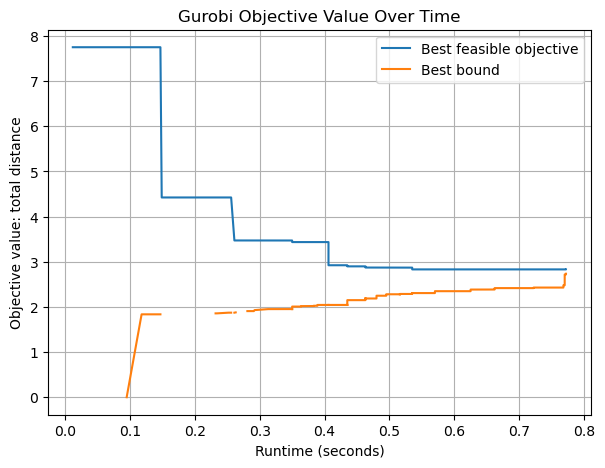


Solving with demand loss limit = 25730


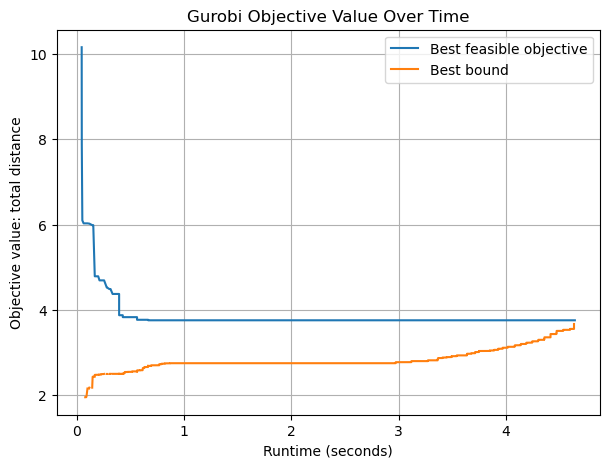


Solving with demand loss limit = 17153


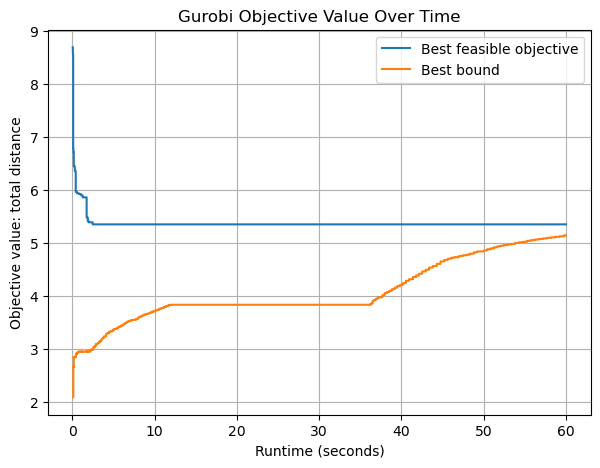


Solving with demand loss limit = 8576


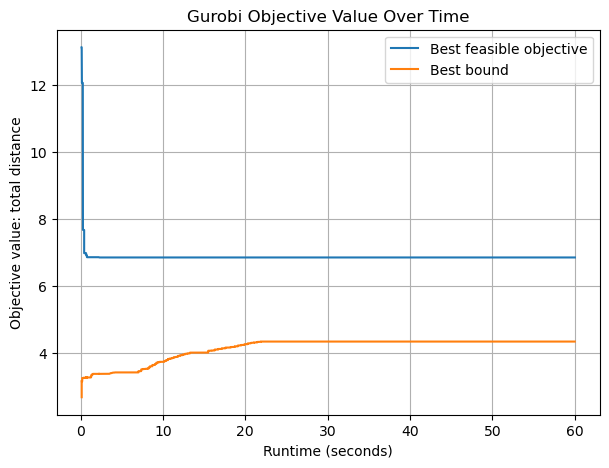


Solving with demand loss limit = 0


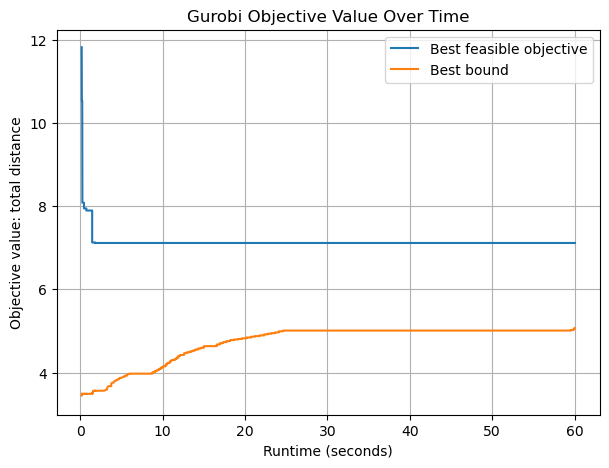


GUROBI EPSILON-CONSTRAINT RESULTS USING REAL DATA
Solution   Epsilon      Distance        Demand Loss     Served Demand   Runtime    MIP Gap   
1          34307        2.831           33354.5         23824.6         0.772      0.00000   
2          25730        3.759           23824.6         33354.5         4.643      0.00000   
3          17153        5.348           14294.8         42884.3         60.036     0.03840   
4          8576         6.852           4764.9          52414.2         60.021     0.36697   
5          0            7.116           0.0             57179.1         60.026     0.28758   

----------------------------------------------------------------------------------------------------
Solution 1
----------------------------------------------------------------------------------------------------
Epsilon:       34307
Total distance: 2.831 km
Demand loss:    33354.5
Served demand:  23824.6

Unserved stops:
['76191', '76229', '76241', '76231', '76221', '76249', '7623

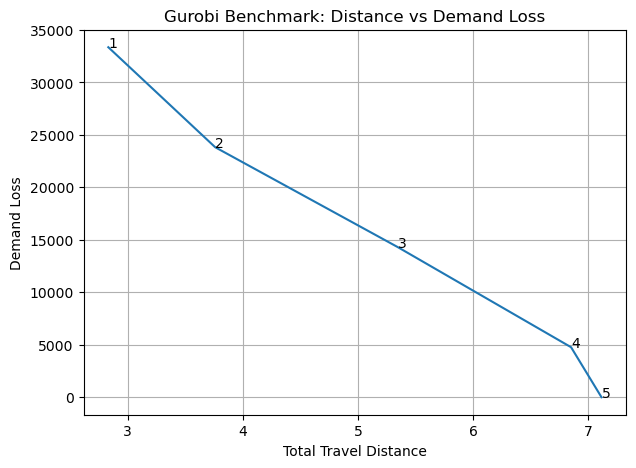

In [9]:
#ver 3
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum


# ============================================================
# 1. Load datasets
# ============================================================

def load_real_data_for_gurobi(
    matched_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\matched_bus_stops_all_services.csv",
    passenger_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\filtered data\\total passenger vol.csv",
    dist_paths=None,
    services=(4, 19, 20),
    depot_code=75009,
    peak_period_keyword="morning",
    max_candidate_stops=12
):
    """
    Inputs used:
        1. matched_bus_stops_all_services.csv
           - contains BUS_SERVICE, BUS_STOP_NUM, longitude, latitude

        2. dist from origin 4.csv / 19.csv / 20.csv
           - contains original route stop sequence and distance between stops

        3. total passenger vol.csv
           - contains aggregate passenger volume by time period

    Returns:
        nodes, stops, depot, services, coords, distance, demand, node_to_code, route_seq
    """

    if dist_paths is None:
        dist_paths = {
            4: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 4.csv",
            19: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 19.csv",
            20: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 20.csv",
        }

    services = [str(s) for s in services] #basically the integer 'z'
    depot_code = str(depot_code) #tampines interchange acts as the 'depot' in our case

    # ------------------------------------------------------------
    # Load bus stop location data
    # ------------------------------------------------------------

    matched = pd.read_csv(matched_path)
    matched["BUS_SERVICE"] = matched["BUS_SERVICE"].astype(str)
    matched["BUS_STOP_NUM"] = matched["BUS_STOP_NUM"].astype(str)

    # ------------------------------------------------------------
    # Load route sequence and known consecutive route distances
    # ------------------------------------------------------------

    route_seq = {}
    appearance_count = {}
    known_arc_distance = {}
    candidate_codes = set()

    for svc, path in dist_paths.items():
        svc = str(svc)

        df = pd.read_csv(path)
        df["Bus Stop Code"] = df["Bus Stop Code"].astype(str)

        seq = df["Bus Stop Code"].tolist()
        route_seq[svc] = seq

        candidate_codes.update(seq)

        for code in seq:
            appearance_count[code] = appearance_count.get(code, 0) + 1

        # Using the actual distance between consecutive stops where available
        for idx in range(1, len(df)):
            prev_code = str(df.loc[idx - 1, "Bus Stop Code"])
            curr_code = str(df.loc[idx, "Bus Stop Code"])
            leg_distance = float(df.loc[idx, "Distance between stops"])

            if leg_distance > 0:
                known_arc_distance[(prev_code, curr_code)] = leg_distance

    candidate_codes.add(depot_code)

    # ------------------------------------------------------------
    # Get coordinates for candidate stops
    # ------------------------------------------------------------

    loc = matched[
        matched["BUS_SERVICE"].isin(services)
        & matched["BUS_STOP_NUM"].isin(candidate_codes)
    ].copy()

    loc = loc.drop_duplicates(subset=["BUS_STOP_NUM"])[
        ["BUS_STOP_NUM", "longitude", "latitude"]
    ]

    # Ensure depot is included
    if depot_code not in set(loc["BUS_STOP_NUM"]):
        depot_row = matched[
            matched["BUS_STOP_NUM"] == depot_code
        ].drop_duplicates(subset=["BUS_STOP_NUM"])[
            ["BUS_STOP_NUM", "longitude", "latitude"]
        ]

        loc = pd.concat([loc, depot_row], ignore_index=True)

    coords_by_code = {
        str(row["BUS_STOP_NUM"]): (
            float(row["longitude"]),
            float(row["latitude"])
        )
        for _, row in loc.iterrows()
    }

    # Keep only stops where coordinates are available
    candidate_codes = [
        code for code in candidate_codes
        if code in coords_by_code
    ]

    # ------------------------------------------------------------
    # Load passenger demand
    # ------------------------------------------------------------

    pax = pd.read_csv(passenger_path) #read passenger volume data

    lower_cols = {
        c.lower().strip(): c
        for c in pax.columns
    }

    # Try to detect stop-level passenger demand if available
    stop_col = None
    for possible_col in [
        "bus stop code",
        "bus_stop_code",
        "bus_stop_num",
        "pt_code"
    ]:
        if possible_col in lower_cols:
            stop_col = lower_cols[possible_col]
            break

    demand_col = None
    for possible_col in [
        "sum of tap in/out",
        "total",
        "demand",
        "passenger demand",
        "tap in"
    ]:
        if possible_col in lower_cols:
            demand_col = lower_cols[possible_col]
            break

    demand_by_code = {}

    if stop_col is not None and demand_col is not None:
        # e.g. passenger file has stop-level demand
        pax[stop_col] = pax[stop_col].astype(str)

        stop_demand = (
            pax[pax[stop_col].isin(candidate_codes)]
            .groupby(stop_col)[demand_col]
            .mean()
        )

        demand_by_code = {
            str(code): float(value)
            for code, value in stop_demand.items()
        }

    else:
        # passenger file only has aggregate demand by time period
        # distribute total peak demand across stops using how freq a route appears

        # Detect rows matching the chosen peak period
        period_mask = pd.Series(False, index=pax.index)

        for col in pax.columns:
            period_mask |= pax[col].astype(str).str.contains(
                peak_period_keyword,
                case=False,
                na=False
            )

        if period_mask.any():
            pax_peak = pax[period_mask]
        else:
            pax_peak = pax

        if demand_col is None:
            numeric_cols = pax_peak.select_dtypes(include=[np.number]).columns.tolist()
            demand_col = numeric_cols[-1]

        total_peak_demand = float(pax_peak[demand_col].mean())

        demand_stop_codes = [
            code for code in candidate_codes
            if code != depot_code
        ]

        weights = np.array([
            max(1, appearance_count.get(code, 1))
            for code in demand_stop_codes
        ], dtype=float)

        weights = weights / weights.sum()

        for code, weight in zip(demand_stop_codes, weights):
            demand_by_code[code] = total_peak_demand * weight

    # depot has no demand loss because it is the start/end point
    demand_by_code[depot_code] = 0.0

    # ------------------------------------------------------------
    # Select a small-sized instance for Gurobi
    # ------------------------------------------------------------

    non_depot_codes = [
        code for code in candidate_codes
        if code != depot_code
    ]

    # Select top-demand stops only to keep a small sample problem
    selected_stop_codes = sorted(
        non_depot_codes,
        key=lambda code: demand_by_code.get(code, 0),
        reverse=True
    )[:max_candidate_stops]

    node_codes = [depot_code] + selected_stop_codes

    # ------------------------------------------------------------
    # Distance matrix
    # ------------------------------------------------------------

    def haversine_km(code_a, code_b): #use the haversine formula to convert the coordinates
        lon1, lat1 = coords_by_code[code_a]
        lon2, lat2 = coords_by_code[code_b]

        radius = 6371.0

        phi1 = math.radians(lat1)
        phi2 = math.radians(lat2)

        dphi = math.radians(lat2 - lat1)
        dlambda = math.radians(lon2 - lon1)

        a = (
            math.sin(dphi / 2) ** 2
            + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
        )

        return 2 * radius * math.asin(math.sqrt(a))

    distance_by_code = {}

    for i in node_codes:
        for j in node_codes:
            if i == j:
                continue

            # Complete graph distance from coordinates
            distance_value = haversine_km(i, j)

            # If actual consecutive-route distance exists, use it
            if (i, j) in known_arc_distance:
                distance_value = known_arc_distance[(i, j)]

            distance_by_code[(i, j)] = distance_value

    # ------------------------------------------------------------
    # Convert bus stop codes to integer node IDs for Gurobi
    # ------------------------------------------------------------

    code_to_node = {
        code: idx
        for idx, code in enumerate(node_codes)
    }

    node_to_code = {
        idx: code
        for code, idx in code_to_node.items()
    }

    depot = code_to_node[depot_code]

    nodes = [
        code_to_node[code]
        for code in node_codes
    ]

    stops = [
        code_to_node[code]
        for code in selected_stop_codes
    ]

    coords = {
        code_to_node[code]: coords_by_code[code]
        for code in node_codes
    }

    distance = {
        (code_to_node[i], code_to_node[j]): dist
        for (i, j), dist in distance_by_code.items()
    }

    demand = {
        code_to_node[code]: float(demand_by_code.get(code, 0))
        for code in selected_stop_codes
    }

    print("\nLoaded real-data small instance")
    print("=" * 60)
    print(f"Services used: {services}")
    print(f"Interchange: {depot_code}")
    print(f"Number of candidate stops selected: {len(stops)}")
    print(f"Total demand in selected instance: {sum(demand.values()):.2f}")

    print("\nSelected bus stops:")
    for node in stops:
        print(
            f"Node {node:<3} Bus Stop {node_to_code[node]:<8} "
            f"Demand {demand[node]:.2f}"
        )

    return nodes, stops, depot, services, coords, distance, demand, node_to_code, route_seq

# ============================================================
# 2. Solve one epsilon-constraint model
# ============================================================
def solve_bus_route_gurobi(
    nodes,
    stops,
    depot,
    services,
    distance,
    demand,
    max_stops_per_service=4,
    max_distance_per_service=None,
    demand_loss_limit=None,
    time_limit=60,
    verbose=True,
    plot_progress=True
):
    """
    Solves one epsilon-constraint version of the bi-objective bus route redesign problem.

    Objective:
        Minimise total travel distance.

    Constraint:
        Demand loss <= demand_loss_limit.

    Also records Gurobi objective value over time using a callback.
    """

    model = Model("bus_route_redesign_mtsp")

    if not verbose:
        model.Params.OutputFlag = 0

    model.Params.TimeLimit = time_limit

    Z = services
    N = nodes
    V = stops
    K = max_stops_per_service

    # ------------------------------------------------------------
    # Decision variables
    # ------------------------------------------------------------

    x = {}

    for z in Z:
        for i in N:
            for j in N:
                if i != j:
                    x[z, i, j] = model.addVar(
                        vtype=GRB.BINARY,
                        name=f"x_{z}_{i}_{j}"
                    )

    y = {}

    for z in Z:
        for i in V:
            y[z, i] = model.addVar(
                vtype=GRB.BINARY,
                name=f"y_{z}_{i}"
            )

    u = {}

    for i in V:
        u[i] = model.addVar(
            vtype=GRB.BINARY,
            name=f"u_{i}"
        )

    order = {}

    for z in Z:
        for i in V:
            order[z, i] = model.addVar(
                lb=0,
                ub=K,
                vtype=GRB.CONTINUOUS,
                name=f"order_{z}_{i}"
            )

    model.update()

    # ------------------------------------------------------------
    # Constraints
    # ------------------------------------------------------------

    # Each service leaves depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, depot, j] for j in V) == 1,
            name=f"depart_depot_{z}"
        )

    # Each service returns depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, i, depot] for i in V) == 1,
            name=f"return_depot_{z}"
        )

    # Link route flow to assignment
    for z in Z:
        for i in V:
            model.addConstr(
                quicksum(x[z, i, j] for j in N if j != i) == y[z, i],
                name=f"outflow_link_{z}_{i}"
            )

            model.addConstr(
                quicksum(x[z, j, i] for j in N if j != i) == y[z, i],
                name=f"inflow_link_{z}_{i}"
            )

       

    # Coverage variable
    # if u[i] = 1, at least 1 service must visit stop i
    for i in V:
        model.addConstr(
            u[i] <= quicksum(y[z, i] for z in Z),
            name=f"coverage_upper_{i}"
        )
        # If any service z visits stop i, then u[i] must be 1
        for z in Z:
            model.addConstr(
                u[i] >= y[z, i],
                name=f"coverage_lower_{z}_{i}"
            )

    # Maximum stops per service
    for z in Z:
        model.addConstr(
            quicksum(y[z, i] for i in V) <= K,
            name=f"max_stops_service_{z}"
        )

    # Optional maximum distance per service
    if max_distance_per_service is not None:
        for z in Z:
            model.addConstr(
                quicksum(
                    distance[i, j] * x[z, i, j]
                    for i in N
                    for j in N
                    if i != j
                ) <= max_distance_per_service,
                name=f"max_route_distance_{z}"
            )

    # MTZ subtour elimination
    for z in Z:
        for i in V:
            model.addConstr(
                order[z, i] >= y[z, i],
                name=f"order_lower_{z}_{i}"
            )

            model.addConstr(
                order[z, i] <= K * y[z, i],
                name=f"order_upper_{z}_{i}"
            )

        for i in V:
            for j in V:
                if i != j:
                    model.addConstr(
                        order[z, i] - order[z, j] + K * x[z, i, j]
                        <= K - 1,
                        name=f"mtz_{z}_{i}_{j}"
                    )

    # Demand loss
    total_demand = sum(demand[i] for i in V)

    served_demand = quicksum(
        demand[i] * u[i]
        for i in V
    )

    demand_loss = total_demand - served_demand

    if demand_loss_limit is not None:
        model.addConstr(
            demand_loss <= demand_loss_limit,
            name="demand_loss_limit"
        )

    # Total travel distance objective
    total_distance = quicksum(
        distance[i, j] * x[z, i, j]
        for z in Z
        for i in N
        for j in N
        if i != j
    )

    model.setObjective(total_distance, GRB.MINIMIZE)

    # ------------------------------------------------------------
    # Callback storage
    # ------------------------------------------------------------

    progress = {
        "time": [],
        "incumbent": [],
        "best_bound": []
    }

    def mip_callback(model, where):
        if where == GRB.Callback.MIP:
            runtime = model.cbGet(GRB.Callback.RUNTIME)
            best_obj = model.cbGet(GRB.Callback.MIP_OBJBST)
            best_bound = model.cbGet(GRB.Callback.MIP_OBJBND)

            if best_obj < GRB.INFINITY:
                progress["time"].append(runtime)
                progress["incumbent"].append(best_obj)
                progress["best_bound"].append(best_bound)

        elif where == GRB.Callback.MIPSOL:
            runtime = model.cbGet(GRB.Callback.RUNTIME)
            best_obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)

            progress["time"].append(runtime)
            progress["incumbent"].append(best_obj)
            progress["best_bound"].append(None)

    
    # ------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------

    model.optimize(mip_callback)

    # ------------------------------------------------------------
    # only access .X if Gurobi found at least one feasible solution
    # ------------------------------------------------------------

    if model.SolCount == 0:
        print("No feasible solution found.")
        print("Gurobi status:", model.Status)
        return None

    # ------------------------------------------------------------
    # Extract routes safely
    # ------------------------------------------------------------

    routes = {}

    for z in Z:
        route = [depot]
        current = depot
        visited_in_route = set()

        while True:
            next_node = None

            for j in N:
                if current != j and (z, current, j) in x:
                    if x[z, current, j].X > 0.5:
                        next_node = j
                        break

            if next_node is None:
                break

            route.append(next_node)

            if next_node == depot:
                break

            if next_node in visited_in_route:
                print(f"Warning: repeated node detected in route for service {z}")
                break

            visited_in_route.add(next_node)
            current = next_node

        routes[z] = route

    selected_stops = [
        i for i in V
        if u[i].X > 0.5
    ]

    unserved_stops = [
        i for i in V
        if u[i].X < 0.5
    ]

    result = {
        "status": model.Status,
        "objective_distance": total_distance.getValue(),
        "demand_loss": demand_loss.getValue(),
        "served_demand": served_demand.getValue(),
        "total_demand": total_demand,
        "runtime": model.Runtime,
        "mip_gap": model.MIPGap if model.SolCount > 0 else None,
        "routes": routes,
        "selected_stops": selected_stops,
        "unserved_stops": unserved_stops,
        "demand": demand,
        "progress": progress
    }

    

    # ------------------------------------------------------------
    # Plot objective value over time
    # ------------------------------------------------------------
    
    
    if plot_progress and len(progress["time"]) > 0:
        plt.figure(figsize=(7, 5))
        plt.plot(progress["time"], progress["incumbent"], label="Best feasible objective")
        plt.plot(progress["time"], progress["best_bound"], label="Best bound")
        plt.xlabel("Runtime (seconds)")
        plt.ylabel("Objective value: total distance")
        plt.title("Gurobi Objective Value Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    return result


    # ------------------------------------------------------------
    # epsilon constraint
    # ------------------------------------------------------------

def run_epsilon_constraint_experiment_real_data():
    (
        nodes,
        stops,
        depot,
        services,
        coords,
        distance,
        demand,
        node_to_code,
        route_seq
    ) = load_real_data_for_gurobi(
        matched_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\matched_bus_stops_all_services.csv",
        passenger_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\filtered data\\total passenger vol.csv",
        dist_paths={
            4: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 4.csv",
            19: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 19.csv",
            20: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 20.csv",
        },
        services=(4, 19, 20),
        depot_code=75009,
        peak_period_keyword="morning",
        max_candidate_stops=12
    )

    total_demand = sum(demand[i] for i in stops)

    # Maximum stops that can be visited without overlap.
    # This helps create realistic epsilon values.
    max_stops_per_service = 5
    max_coverable_stops = min(
        len(stops),
        len(services) * max_stops_per_service
    )

    top_demands = sorted(
        [demand[i] for i in stops],
        reverse=True
    )

    max_possible_served_demand = sum(top_demands[:max_coverable_stops])
    minimum_possible_demand_loss = total_demand - max_possible_served_demand

    print("\nDemand summary")
    print("=" * 60)
    print(f"Total demand: {total_demand:.2f}")
    print(f"Max coverable stops without overlap: {max_coverable_stops}")
    print(f"Minimum possible demand loss estimate: {minimum_possible_demand_loss:.2f}")

    # Epsilon values for demand loss.
    # Smaller epsilon means the model must serve more demand
    epsilon_values = [
        int(total_demand * 0.60),
        int(total_demand * 0.45),
        int(total_demand * 0.30),
        int(total_demand * 0.15),
        int(max(0, minimum_possible_demand_loss))
    ]

    # Remove duplicates and sort from loose to strict
    epsilon_values = sorted(set(epsilon_values), reverse=True)

    pareto_results = []

    for eps in epsilon_values:
        print(f"\nSolving with demand loss limit = {eps}")

        result = solve_bus_route_gurobi(
            nodes=nodes,
            stops=stops,
            depot=depot,
            services=services,
            distance=distance,
            demand=demand,
            max_stops_per_service=max_stops_per_service,
            max_distance_per_service=None,
            demand_loss_limit=eps,
            time_limit=60,
            verbose=False,
            plot_progress=True
        )

        if result is not None:
            result["epsilon"] = eps
            pareto_results.append(result)
        else:
            print(f"Skipped epsilon = {eps} because no feasible solution was found.")

    # ------------------------------------------------------------
    # Remove duplicate solutions
    # ------------------------------------------------------------

    unique_results = []
    seen = set()

    for result in pareto_results:
        key = (
            round(result["objective_distance"], 4),
            round(result["demand_loss"], 4)
        )

        if key not in seen:
            seen.add(key)
            unique_results.append(result)

    # ------------------------------------------------------------
    # Print summary table
    # ------------------------------------------------------------

    print("\n" + "=" * 100)
    print("GUROBI EPSILON-CONSTRAINT RESULTS USING REAL DATA")
    print("=" * 100)

    print(
        f"{'Solution':<10} "
        f"{'Epsilon':<12} "
        f"{'Distance':<15} "
        f"{'Demand Loss':<15} "
        f"{'Served Demand':<15} "
        f"{'Runtime':<10} "
        f"{'MIP Gap':<10}"
    )

    for idx, result in enumerate(unique_results, start=1):
        print(
            f"{idx:<10} "
            f"{result['epsilon']:<12} "
            f"{result['objective_distance']:<15.3f} "
            f"{result['demand_loss']:<15.1f} "
            f"{result['served_demand']:<15.1f} "
            f"{result['runtime']:<10.3f} "
            f"{result['mip_gap']:<10.5f}"
        )

    # ------------------------------------------------------------
    # Print route details
    # ------------------------------------------------------------

    for idx, result in enumerate(unique_results, start=1):
        print("\n" + "-" * 100)
        print(f"Solution {idx}")
        print("-" * 100)

        print(f"Epsilon:       {result['epsilon']}")
        print(f"Total distance: {result['objective_distance']:.3f} km")
        print(f"Demand loss:    {result['demand_loss']:.1f}")
        print(f"Served demand:  {result['served_demand']:.1f}")

        print("\nUnserved stops:")
        print([node_to_code[i] for i in result["unserved_stops"]])

        print("\nRoutes:")
        for z, route in result["routes"].items():
            route_codes = [
                node_to_code[node]
                for node in route
            ]

            print(f"Service {z}: {route_codes}")

    # ------------------------------------------------------------
    # Plot Pareto-style trade-off
    # ------------------------------------------------------------

    if len(unique_results) > 0:
        plt.figure(figsize=(7, 5))

        plt.plot(
            [r["objective_distance"] for r in unique_results],
            [r["demand_loss"] for r in unique_results]
        )

        for idx, r in enumerate(unique_results, start=1):
            plt.annotate(
                str(idx),
                (r["objective_distance"], r["demand_loss"])
            )

        plt.xlabel("Total Travel Distance")
        plt.ylabel("Demand Loss")
        plt.title("Gurobi Benchmark: Distance vs Demand Loss")
        plt.grid(True)
        plt.show()

    return unique_results, node_to_code


# ============================================================
# 4. Main
# ============================================================

results, node_to_code = run_epsilon_constraint_experiment_real_data()